In [12]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import time

In [13]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

In [14]:
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (224, 224))
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [15]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [16]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d_1   (None, 2048)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_2 (Dense)             (None, 256)               524544    
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_3 (Dense)             (None, 10)                2570      
                                                                 
Total params: 24,114,826
Trainable params: 527,114
Non-trainable params: 23,587,712
____________________________________

In [18]:
start_time = time.time()

history = model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds,
    verbose=1
)

training_time = time.time() - start_time
print(f"\nTraining Time: {training_time:.2f} seconds")

Epoch 1/10
1563/1563 [==============================] - 154s 83ms/step - loss: 2.3171 - accuracy: 0.1103 - val_loss: 2.2940 - val_accuracy: 0.1053
Epoch 2/10
1563/1563 [==============================] - 129s 82ms/step - loss: 2.2900 - accuracy: 0.1296 - val_loss: 2.2806 - val_accuracy: 0.1777
Epoch 3/10
1563/1563 [==============================] - 131s 84ms/step - loss: 2.2737 - accuracy: 0.1479 - val_loss: 2.2595 - val_accuracy: 0.1936
Epoch 4/10
1563/1563 [==============================] - 133s 85ms/step - loss: 2.2521 - accuracy: 0.1621 - val_loss: 2.2333 - val_accuracy: 0.2145
Epoch 5/10
1563/1563 [==============================] - 129s 82ms/step - loss: 2.2248 - accuracy: 0.1738 - val_loss: 2.1999 - val_accuracy: 0.2315
Epoch 6/10
1563/1563 [==============================] - 131s 83ms/step - loss: 2.1980 - accuracy: 0.1881 - val_loss: 2.1742 - val_accuracy: 0.2211
Epoch 7/10
1563/1563 [==============================] - 137s 87ms/step - loss: 2.1751 - accuracy: 0.1954 - val_loss: 2

In [19]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)

print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 24.67%
Test Loss: 2.0845


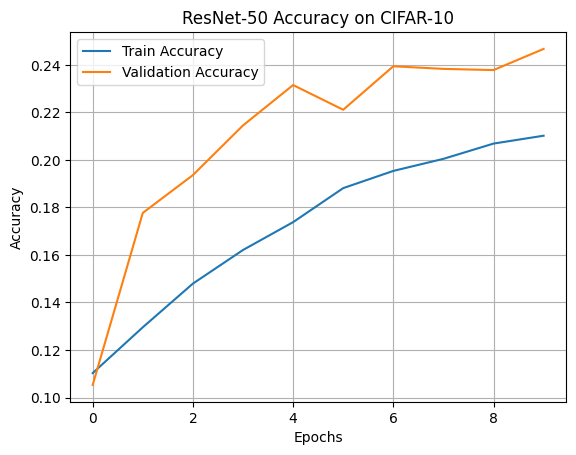

In [20]:
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('ResNet-50 Accuracy on CIFAR-10')
plt.legend()
plt.grid(True)
plt.show()

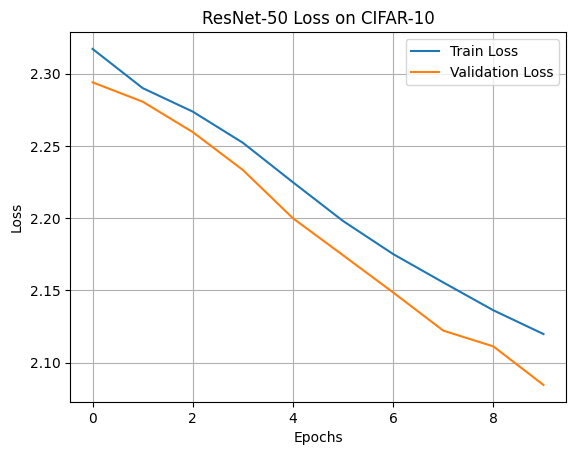

In [21]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ResNet-50 Loss on CIFAR-10')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
print(f"Total Parameters: {model.count_params():,}")

Total Parameters: 24,114,826
